# De onde vem o dinheiro de Uberlândia?

Segundo projeto do portfólio. Pergunta de mesa de bar: quanto a prefeitura arrecada e de onde vem esse dinheiro? A resposta está nos dados que todo município brasileiro é obrigado a enviar ao Tesouro Nacional.

**Fonte dos dados:** [SICONFI](https://siconfi.tesouro.gov.br/), o sistema de contas públicas do Tesouro Nacional. Uso a API pública do datalake, que devolve o RREO (Relatório Resumido de Execução Orçamentária) de qualquer município. O notebook puxa os dados direto da API, sem download manual.

O que busco responder:

- Quanto Uberlândia arrecadou por ano, de 2019 a 2024?
- Quanto vem de impostos próprios (IPTU, ISS etc.) e quanto vem de transferências (União e Estado)?
- Quanto entra por dia no caixa da cidade?

## 1. Setup

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

import os
os.makedirs('graficos', exist_ok=True)

COD_IBGE_UDI = 3170206
print('ok')

ok


## 2. Puxar os dados da API do Tesouro

Uma chamada por ano, pedindo o RREO do 6º bimestre (que fecha o ano), coluna "Até o Bimestre", que é a receita efetivamente realizada. O Anexo 01 é o resumo da execução orçamentária.

In [2]:
def rreo_receitas(ano):
    url = 'https://apidatalake.tesouro.gov.br/ords/siconfi/tt/rreo'
    params = {
        'an_exercicio': ano,
        'nr_periodo': 6,
        'co_tipo_demonstrativo': 'RREO',
        'id_ente': COD_IBGE_UDI,
    }
    dados = requests.get(url, params=params, timeout=120).json()['items']
    linhas = [
        i for i in dados
        if i['anexo'] == 'RREO-Anexo 01' and i['coluna'] == 'Até o Bimestre (c)'
    ]
    df = pd.DataFrame(linhas)[['cod_conta', 'conta', 'valor']]
    df['ano'] = ano
    return df

anos = list(range(2019, 2025))
rreo = pd.concat([rreo_receitas(a) for a in anos], ignore_index=True)
print(f'{len(rreo)} linhas, anos {anos[0]} a {anos[-1]}')
rreo.head(3)

311 linhas, anos 2019 a 2024


,cod_conta,conta,valor,ano
0,ReceitasExcetoIntraOrcamentarias,RECEITAS (EXCETO INTRA-ORÇAMENTÁRIAS) (I),2.336619e+09,2019
1,ReceitasCorrentes,RECEITAS CORRENTES,2.212098e+09,2019
2,ReceitaTributaria,"IMPOSTOS, TAXAS E CONTRIBUIÇÕES DE MELHORIA",5.388967e+08,2019


## 3. Quanto a cidade arrecadou por ano

"Receitas (exceto intra-orçamentárias)" é o total que entrou de fato no caixa, sem as movimentações entre órgãos da própria prefeitura. Atenção: são **valores nominais**, sem correção pela inflação.

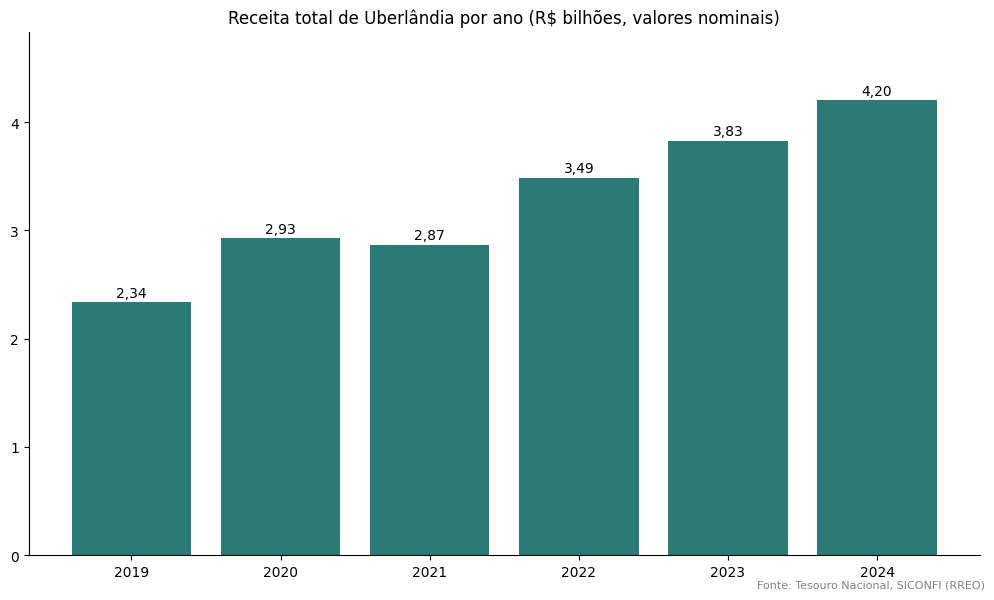

crescimento nominal 2019 a 2024: 80%


In [3]:
total = rreo[rreo['cod_conta'] == 'ReceitasExcetoIntraOrcamentarias'][['ano', 'valor']].reset_index(drop=True)
total['bi'] = total['valor'] / 1e9

fig, ax = plt.subplots()
barras = ax.bar(total['ano'].astype(str), total['bi'], color='#2b7a78')
ax.set_title('Receita total de Uberlândia por ano (R$ bilhões, valores nominais)')
for b, v in zip(barras, total['bi']):
    ax.text(b.get_x() + b.get_width()/2, v + 0.05, f'{v:.2f}'.replace('.', ','), ha='center')
ax.set_ylim(0, total['bi'].max() * 1.15)
fig.text(0.99, 0.01, 'Fonte: Tesouro Nacional, SICONFI (RREO)', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('graficos/receita_total_anual.png', dpi=150, bbox_inches='tight')
plt.show()

crescimento = (total['bi'].iloc[-1] / total['bi'].iloc[0] - 1) * 100
print(f'crescimento nominal {anos[0]} a {anos[-1]}: {crescimento:.0f}%')

## 4. De onde vem o dinheiro

A receita corrente se divide em grandes grupos. Os dois que importam para a conversa:

- **Impostos, taxas e contribuições de melhoria**: o que a cidade arrecada sozinha (IPTU, ISS, taxas).
- **Transferências correntes**: dinheiro que vem da União e do Estado (FPM, ICMS, Fundeb etc.).

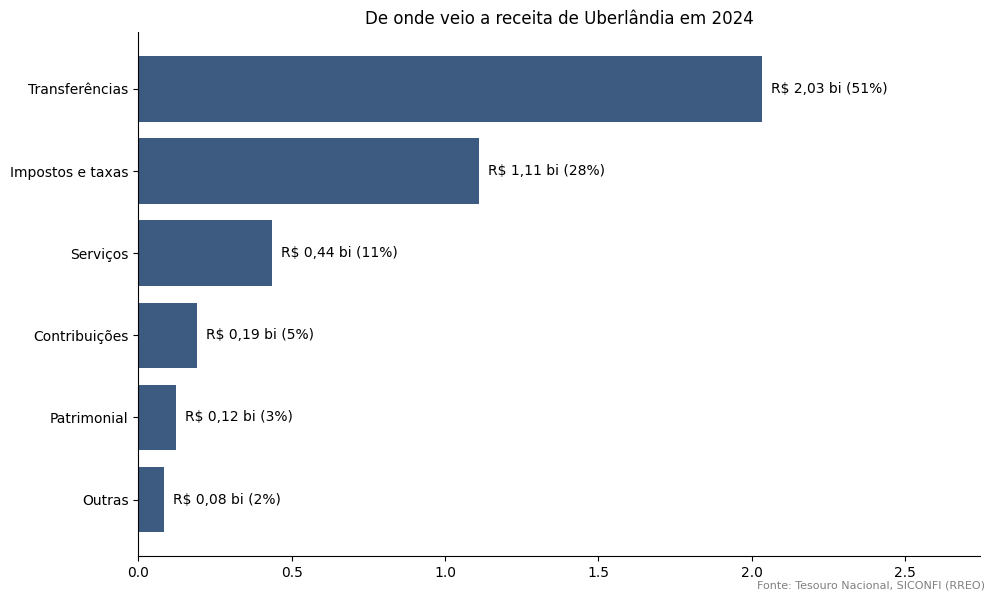

In [4]:
ano_ref = 2024
grupos = {
    'ReceitaTributaria': 'Impostos e taxas',
    'ReceitaDeContribuicoes': 'Contribuições',
    'ReceitaPatrimonial': 'Patrimonial',
    'ReceitaDeServicos': 'Serviços',
    'TransferenciasCorrentes': 'Transferências',
    'OutrasReceitasCorrentes': 'Outras',
}
base = rreo[(rreo['ano'] == ano_ref) & (rreo['cod_conta'].isin(grupos))].copy()
base['grupo'] = base['cod_conta'].map(grupos)
base = base.sort_values('valor')

fig, ax = plt.subplots()
ax.barh(base['grupo'], base['valor'] / 1e9, color='#3d5a80')
total_ano = base['valor'].sum()
for i, v in enumerate(base['valor']):
    ax.text(v / 1e9 + 0.03, i, f'R$ {v/1e9:.2f} bi ({v/total_ano*100:.0f}%)'.replace('.', ','), va='center')
ax.set_title(f'De onde veio a receita de Uberlândia em {ano_ref}')
ax.set_xlim(0, base['valor'].max() / 1e9 * 1.35)
fig.text(0.99, 0.01, 'Fonte: Tesouro Nacional, SICONFI (RREO)', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('graficos/composicao_receita.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Própria x transferida: a dependência em uma imagem

A pergunta que interessa: quanto da receita a cidade controla (impostos próprios) e quanto depende de repasse?

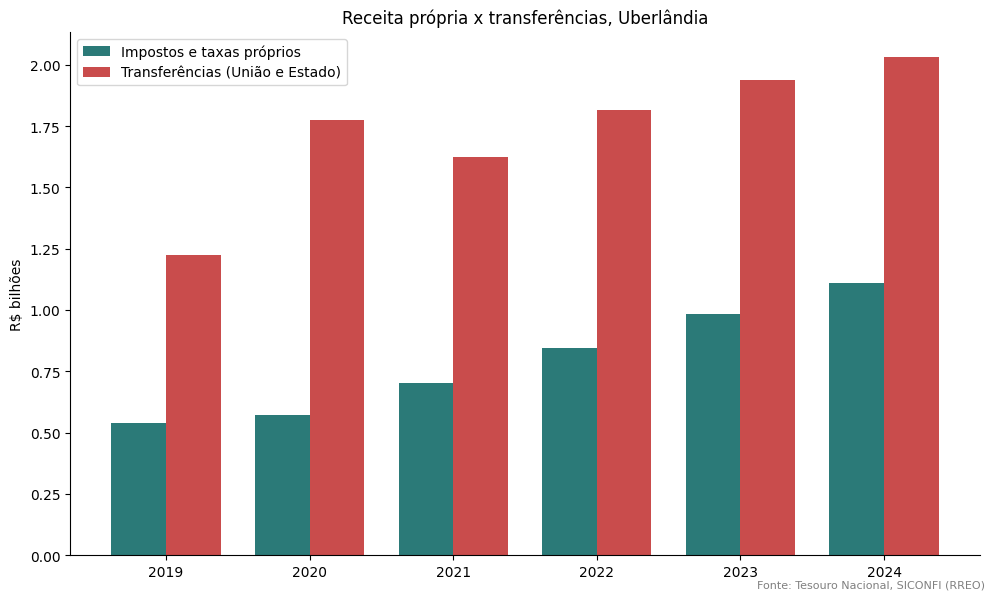

 ano pct_tributaria
2019            31%
2020            24%
2021            30%
2022            32%
2023            34%
2024            35%


In [5]:
trib = rreo[rreo['cod_conta'] == 'ReceitaTributaria'][['ano', 'valor']].rename(columns={'valor': 'tributaria'})
transf = rreo[rreo['cod_conta'] == 'TransferenciasCorrentes'][['ano', 'valor']].rename(columns={'valor': 'transferencias'})
dep = trib.merge(transf, on='ano')
dep['pct_tributaria'] = dep['tributaria'] / (dep['tributaria'] + dep['transferencias']) * 100

fig, ax = plt.subplots()
largura = 0.38
x = range(len(dep))
ax.bar([i - largura/2 for i in x], dep['tributaria'] / 1e9, largura, label='Impostos e taxas próprios', color='#2b7a78')
ax.bar([i + largura/2 for i in x], dep['transferencias'] / 1e9, largura, label='Transferências (União e Estado)', color='#c94c4c')
ax.set_xticks(list(x))
ax.set_xticklabels(dep['ano'].astype(str))
ax.set_ylabel('R$ bilhões')
ax.set_title('Receita própria x transferências, Uberlândia')
ax.legend()
fig.text(0.99, 0.01, 'Fonte: Tesouro Nacional, SICONFI (RREO)', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('graficos/propria_vs_transferencias.png', dpi=150, bbox_inches='tight')
plt.show()

print(dep[['ano', 'pct_tributaria']].to_string(index=False, formatters={'pct_tributaria': '{:.0f}%'.format}))

## 6. Quanto entra por dia

Número pronto para conversa: a receita do ano dividida por 365.

In [6]:
receita_2024 = total.loc[total['ano'] == 2024, 'valor'].iloc[0]
por_dia = receita_2024 / 365
por_hora = por_dia / 24

print(f'receita 2024:  R$ {receita_2024/1e9:.2f} bilhões'.replace('.', ','))
print(f'por dia:       R$ {por_dia/1e6:.1f} milhões'.replace('.', ','))
print(f'por hora:      R$ {por_hora/1e3:.0f} mil'.replace('.', ','))

receita 2024:  R$ 4,20 bilhões
por dia:       R$ 11,5 milhões
por hora:      R$ 480 mil


## 7. O que eu tiro disso

- Uberlândia arrecadou **R$ 4,2 bilhões em 2024**, contra R$ 2,3 bilhões em 2019. Crescimento nominal de 80% em cinco anos (sem descontar a inflação, que come uma parte boa desse aumento).
- **Metade da receita corrente vem de transferências**: R$ 2,03 bilhões (51%) chegam da União e do Estado. Impostos e taxas próprios somam R$ 1,11 bilhão (28%).
- A fatia de receita própria vem subindo devagar: era 31% do bolo "própria + transferências" em 2019 e chegou a 35% em 2024.
- Número de conversa: entram **R$ 11,5 milhões por dia** no caixa da prefeitura, ou R$ 480 mil por hora.

Limitação honesta: o SICONFI mostra os grandes grupos. O detalhe imposto a imposto (IPTU x ISS, por exemplo) está no painel de receitas da prefeitura, que não tem API pública; fica para uma análise futura com coleta manual.